# SHAP / XAI Analysis — Patrol Forecast v6 Ensemble

**Flipkart GridLock Hackathon 2.0**  
Explainable AI (XAI) analysis of the `production_v6.pkl` model.

| # | Graph Type | Purpose |
|---|-----------|----------|
| 1 | **SHAP Beeswarm (Summary) Plot** | Feature importance with directional impact |
| 2 | **Global Feature Importance Bar Plot** | Mean |SHAP| value ranking |
| 3 | **SHAP Dependence Scatter Plots** | Non-linear feature-prediction relationships |
| 4 | **SHAP Waterfall Plot** | Step-by-step breakdown of a high-risk prediction |
| 5 | **SHAP Force Plot** | Red/blue force diagram for single prediction |
| 6 | **SHAP Heatmap** | Multi-sample patterns revealing prediction clusters |

All plots saved as **300 DPI PNGs** in `shap_plots/`.

---
## Setup & Imports

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import joblib
import shap
import xgboost as xgb
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

%matplotlib inline
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'Arial', 'Helvetica', 'sans-serif'],
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight'
})

PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
MODEL_DIR = os.path.join(PROJECT_DIR, 'model')
sys.path.insert(0, MODEL_DIR)

import features_v6 as F

PLOT_DIR = os.path.join(PROJECT_DIR, 'shap_plots')
os.makedirs(PLOT_DIR, exist_ok=True)

print(f'SHAP     : {shap.__version__}')
print(f'XGBoost  : {xgb.__version__}')
print(f'Plot dir : {PLOT_DIR}')
print('Setup complete!')

C:\Users\WELCOME\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP     : 0.49.1
XGBoost  : 3.2.0
Plot dir : C:\Users\WELCOME\Desktop\Flipkart\shap_plots
Setup complete!


---
## Load Model Bundle

In [2]:
BUNDLE_PATH = os.path.join(MODEL_DIR, 'production_v6.pkl')
bundle = joblib.load(BUNDLE_PATH)

print('Bundle keys:', list(bundle.keys()))
print('24h heads  :', list(bundle['24h'].keys()))
print('Ridge weights (24h) [xgb, hurdle, glm, quantile]:', bundle['24h']['ridge_w'])

xgb_24h = bundle['24h']['xgb']
print(f'\nLoaded {os.path.basename(BUNDLE_PATH)} ({os.path.getsize(BUNDLE_PATH)/1e6:.1f} MB)')

Bundle keys: ['feats_num', 'feats_xgb', 'feats_lgb', 'feats_cat', 'cat_idx', 'station_cats', 'best_params', '24h', '48h', 'rank', 'severity_quantiles', 'attrs']
24h heads  : ['xgb', 'clf', 'cat', 'quant', 'glm', 'scaler', 'glm_enc', 'glm_cols', 'ridge_w']
Ridge weights (24h) [xgb, hurdle, glm, quantile]: [0.2698717097373262, 0.3127122658312869, 0.40737058947978255, 0.010045434261110008]

Loaded production_v6.pkl (45.9 MB)


---
## Load Data & Build Features

In [3]:
CSV_PATH = os.path.join(MODEL_DIR, 'seed_upload.csv')
clean_df = F.load_clean(CSV_PATH)
print(f'Clean data rows : {len(clean_df):,}')

panel, keep, attrs = F.build_panel(clean_df)
panel['station'] = panel['station'].cat.set_categories(bundle['station_cats'])
print(f'Panel shape     : {panel.shape}')
print(f'Modeled H3 cells: {len(keep)}')

latest = panel[panel.date == panel.date.max()].copy()
print(f'Latest day rows : {len(latest)}')

last_7d = panel[
    panel.date >= panel.date.max() - pd.Timedelta(days=7)
].dropna(subset=['y_t1']).copy()
print(f'Last-7-day rows : {len(last_7d)}')

print('Feature panel built!')

Clean data rows : 23,319


Panel shape     : (1848, 93)
Modeled H3 cells: 66
Latest day rows : 66
Last-7-day rows : 462
Feature panel built!


---
## Compute SHAP Values

Uses **XGBoost's native TreeSHAP** via `pred_contribs=True` to avoid SHAP library version issues,  
then wraps results in `shap.Explanation` objects for all standard SHAP plots.

In [4]:
# Separate numeric and categorical for safe cleaning
NUM_COLS = [c for c in F.FEATS_XGB if c != 'station']

def prepare_X(df):
    X = df[F.FEATS_XGB].copy()
    X[NUM_COLS] = X[NUM_COLS].replace([np.inf, -np.inf], 0).fillna(0)
    return X

X_latest = prepare_X(latest)

sample_n = min(500, len(last_7d))
X_sample = prepare_X(last_7d.sample(n=sample_n, random_state=42))

print(f'X_latest : {X_latest.shape}')
print(f'X_sample : {X_sample.shape}')

# ── XGBoost native TreeSHAP ──
booster = xgb_24h.get_booster()

def compute_shap_native(X_df):
    """Use XGBoost's built-in TreeSHAP (pred_contribs). Returns shap.Explanation."""
    dm = xgb.DMatrix(X_df, enable_categorical=True)
    contribs = booster.predict(dm, pred_contribs=True)
    # Shape: (n_samples, n_features + 1). Last col = base value (bias term).
    base_val = float(contribs[0, -1])
    sv = contribs[:, :-1]
    return shap.Explanation(
        values=sv,
        base_values=np.full(len(sv), base_val),
        data=X_df.values,
        feature_names=list(X_df.columns)
    ), base_val

print('Computing SHAP values (native XGBoost TreeSHAP)...')
shap_latest, base_value = compute_shap_native(X_latest)
shap_sample, _          = compute_shap_native(X_sample)

print(f'SHAP latest : {shap_latest.shape}')
print(f'SHAP sample : {shap_sample.shape}')
print(f'Base value   : {base_value:.4f}')

# Top features ranking
mean_abs_shap = np.abs(shap_sample.values).mean(axis=0)
feat_ranking = np.argsort(mean_abs_shap)[::-1]
numeric_ranking = [i for i in feat_ranking if F.FEATS_XGB[i] in F.FEATS_NUM]
top1_feat = F.FEATS_XGB[numeric_ranking[0]]
top2_feat = F.FEATS_XGB[numeric_ranking[1]]

print(f'\nTop 5 features by mean |SHAP|:')
for rank, idx in enumerate(feat_ranking[:5]):
    print(f'  {rank+1}. {F.FEATS_XGB[idx]:30s}  {mean_abs_shap[idx]:.4f}')

print('\nSHAP computation complete!')

X_latest : (66, 78)
X_sample : (462, 78)
Computing SHAP values (native XGBoost TreeSHAP)...


SHAP latest : (66, 78)
SHAP sample : (462, 78)
Base value   : 0.9858

Top 5 features by mean |SHAP|:
  1. ewm_28                          0.4033
  2. cell_rank                       0.3219
  3. station                         0.1001
  4. cell_expanding_mean             0.0786
  5. roll_mean_21                    0.0671

SHAP computation complete!


---
# XAI Visualizations

## Graph 1: SHAP Beeswarm (Summary) Plot

Each dot = one prediction. X-axis = SHAP impact.  
Color: red = high feature value, blue = low. Shows **direction + magnitude** of every feature.

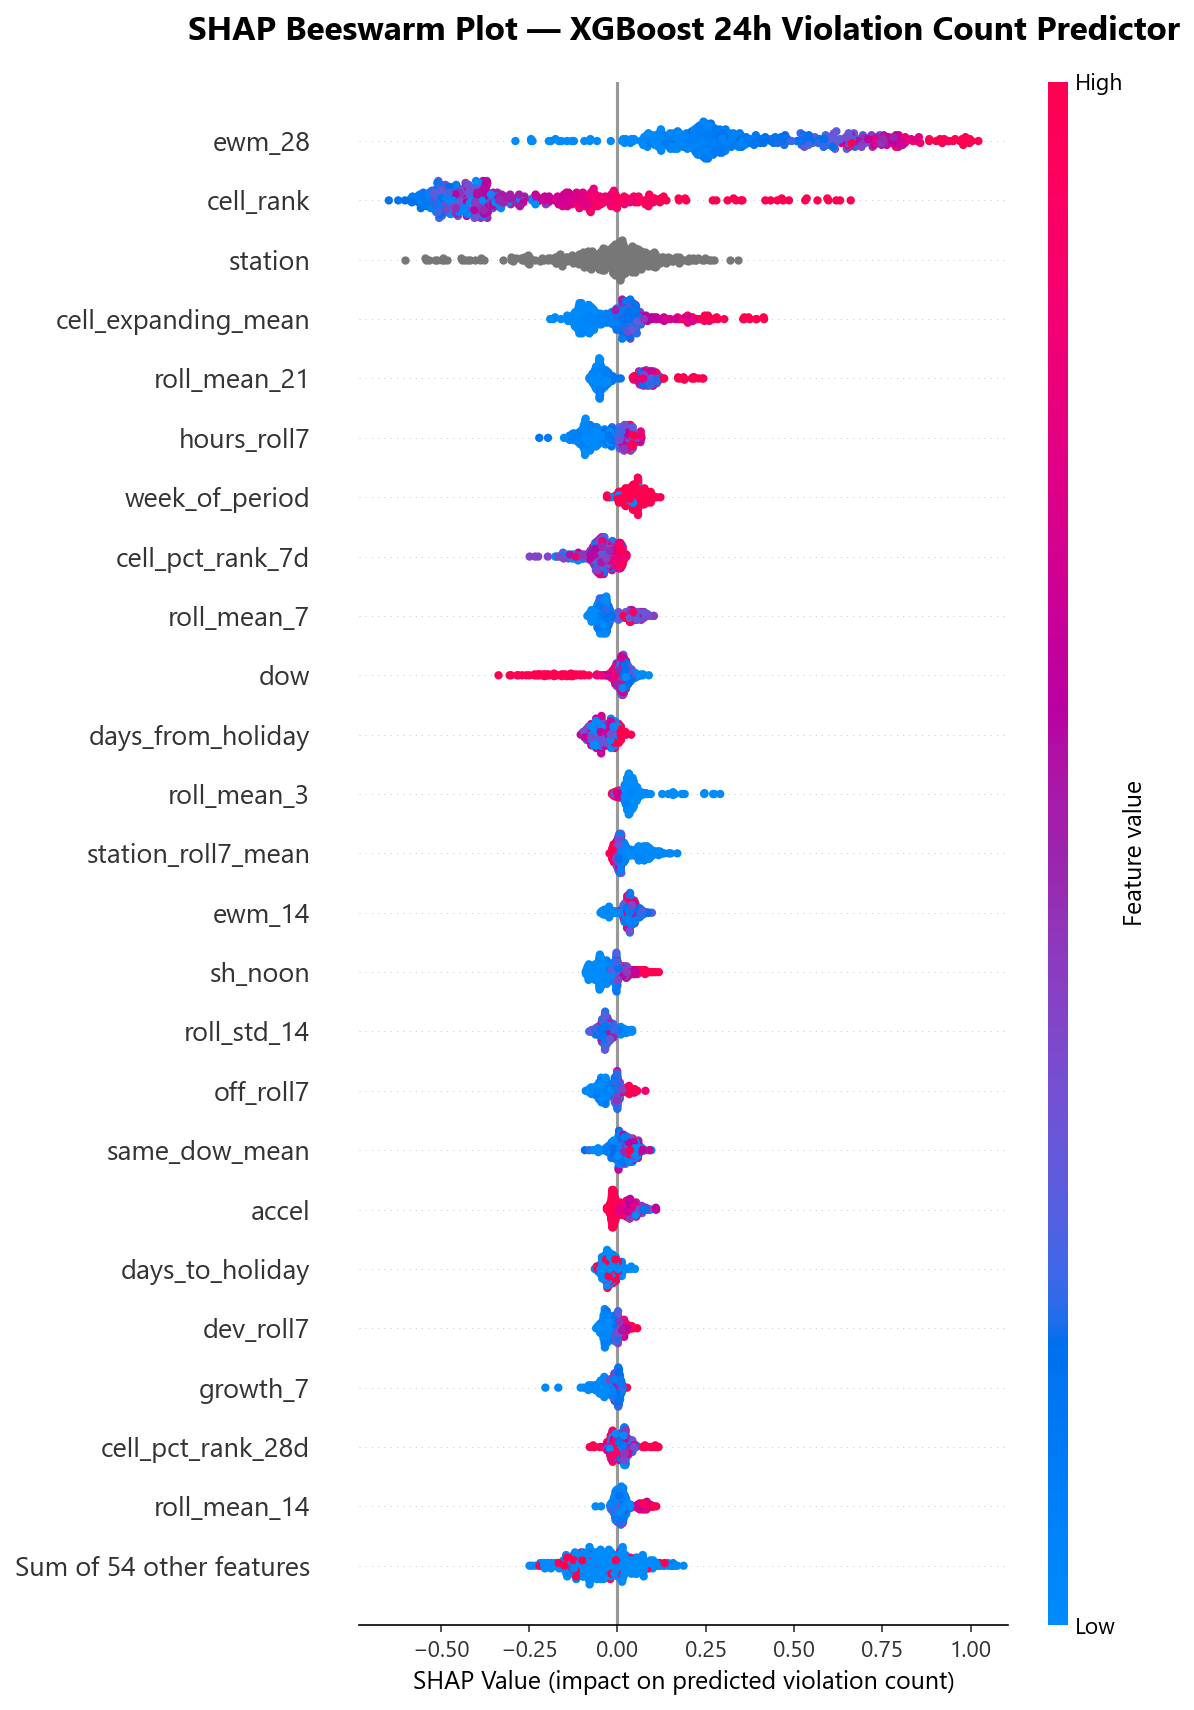

Saved: shap_plots/1_shap_beeswarm_summary.png


In [5]:
plt.figure(figsize=(14, 10))
shap.plots.beeswarm(
    shap_sample,
    max_display=25,
    show=False
)
plt.title(
    'SHAP Beeswarm Plot \u2014 XGBoost 24h Violation Count Predictor',
    fontsize=16, fontweight='bold', pad=20
)
plt.xlabel('SHAP Value (impact on predicted violation count)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '1_shap_beeswarm_summary.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: shap_plots/1_shap_beeswarm_summary.png')

---
## Graph 2: Global Feature Importance (Mean |SHAP|)

Average absolute SHAP value per feature. The most **reliable importance metric** \u2014 captures both linear and non-linear contributions.

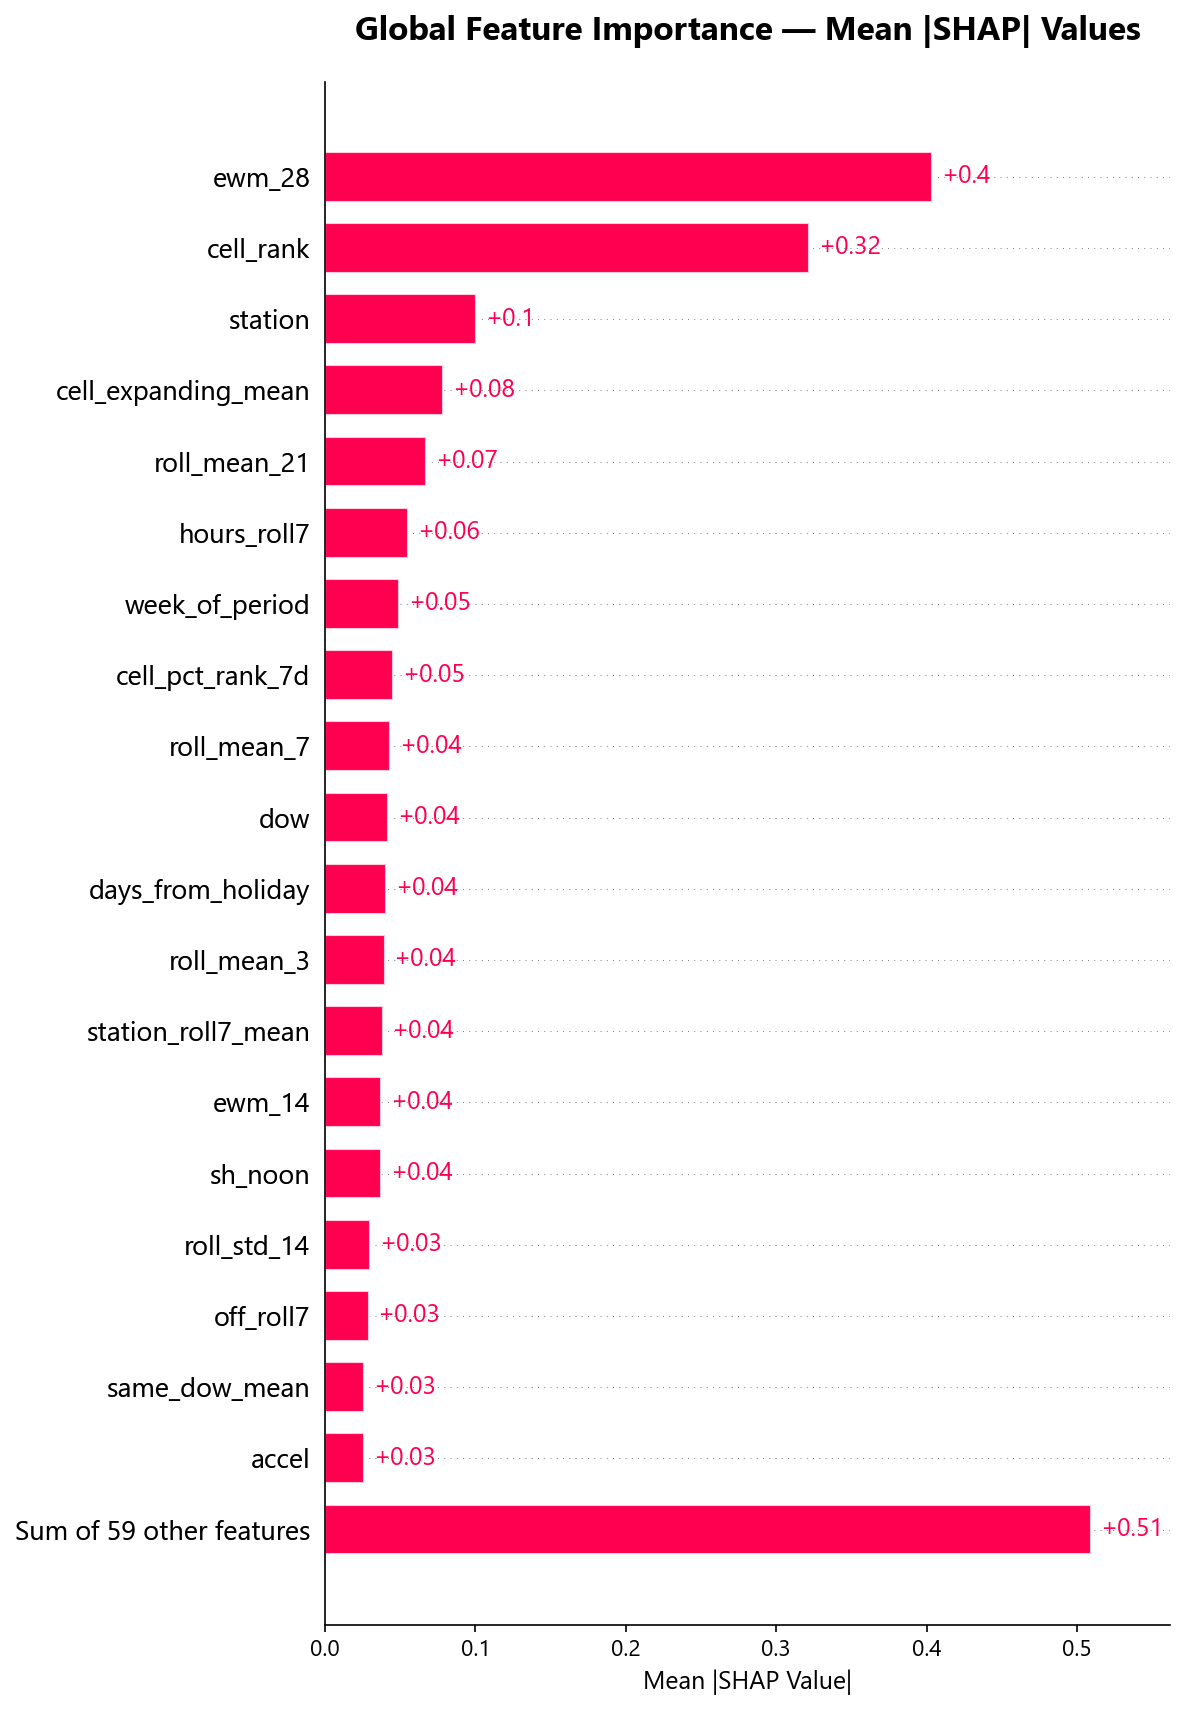

Saved: shap_plots/2_shap_feature_importance_bar.png


In [6]:
plt.figure(figsize=(12, 10))
shap.plots.bar(
    shap_sample,
    max_display=20,
    show=False
)
plt.title(
    'Global Feature Importance \u2014 Mean |SHAP| Values',
    fontsize=16, fontweight='bold', pad=20
)
plt.xlabel('Mean |SHAP Value|', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '2_shap_feature_importance_bar.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: shap_plots/2_shap_feature_importance_bar.png')

---
## Graph 3: SHAP Dependence Scatter Plots

Shows how individual feature values relate to their SHAP contribution.  
Reveals **non-linear effects** and **feature interactions** (color = auto-detected interacting feature).

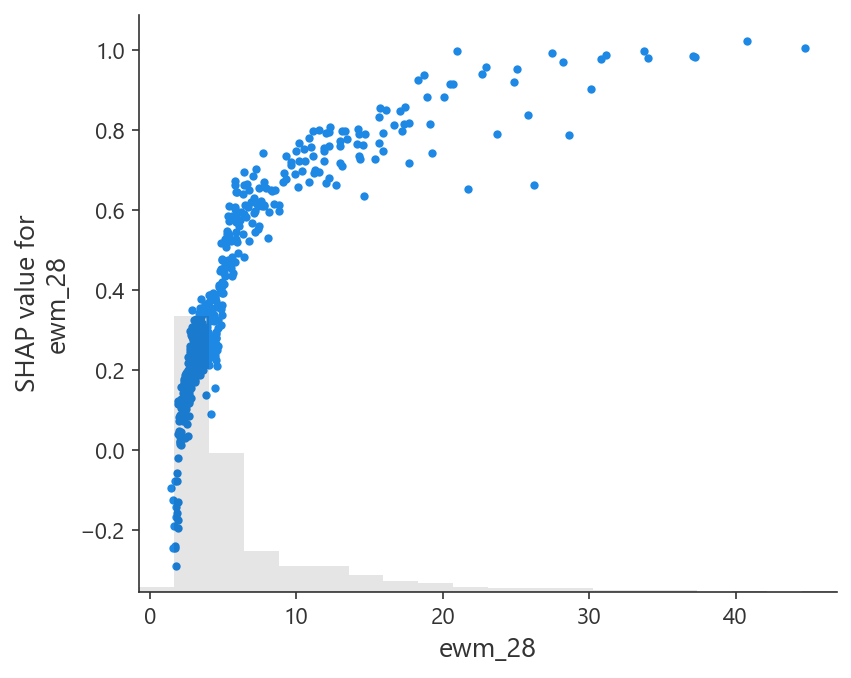

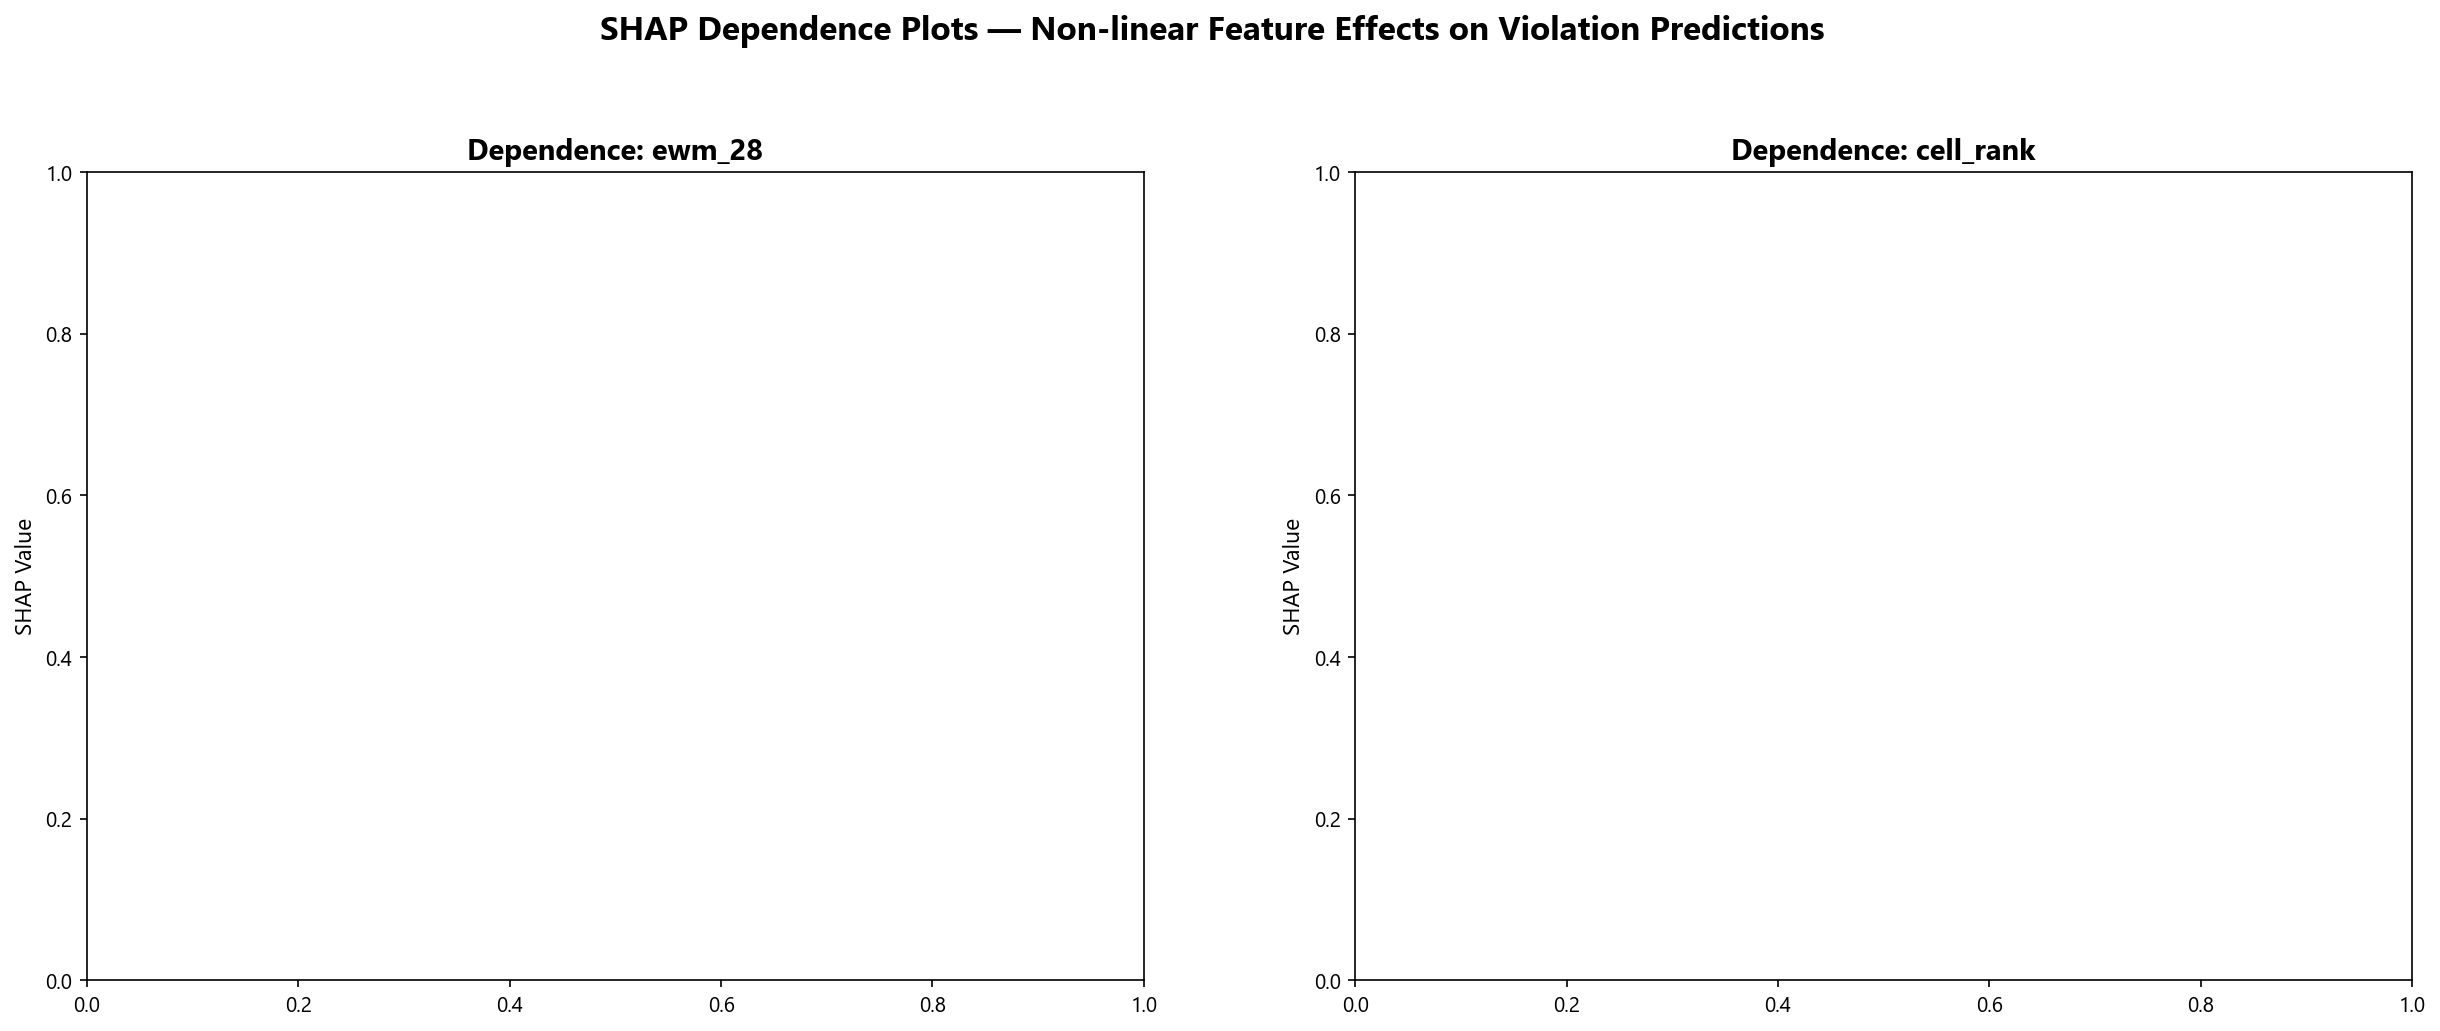

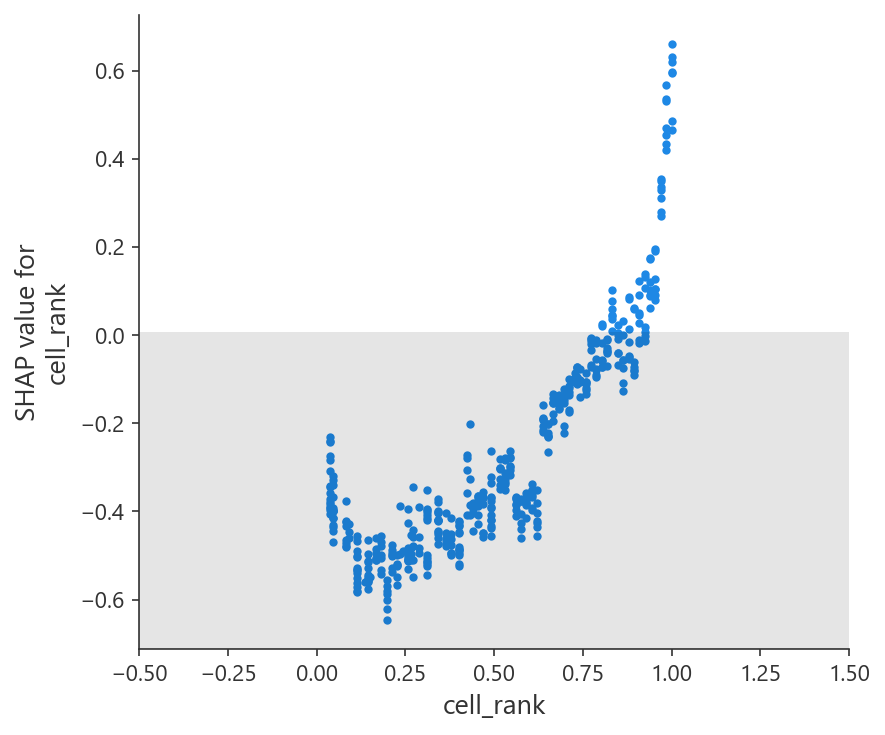

Saved: shap_plots/3_shap_dependence_scatter.png
Features shown: ewm_28, cell_rank


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

plt.sca(axes[0])
shap.plots.scatter(
    shap_sample[:, top1_feat],
    show=False
)
axes[0].set_title(f'Dependence: {top1_feat}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('SHAP Value', fontsize=11)

plt.sca(axes[1])
shap.plots.scatter(
    shap_sample[:, top2_feat],
    show=False
)
axes[1].set_title(f'Dependence: {top2_feat}', fontsize=14, fontweight='bold')
axes[1].set_ylabel('SHAP Value', fontsize=11)

fig.suptitle(
    'SHAP Dependence Plots \u2014 Non-linear Feature Effects on Violation Predictions',
    fontsize=16, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '3_shap_dependence_scatter.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: shap_plots/3_shap_dependence_scatter.png')
print(f'Features shown: {top1_feat}, {top2_feat}')

---
## Graph 4: SHAP Waterfall Plot (Single Prediction)

Step-by-step breakdown of the **highest-risk prediction**.  
Starting from base value E[f(x)], each bar shows how a feature pushes the prediction up (red) or down (blue).

Explaining prediction #27
  Base value  : 0.986
  SHAP sum    : +1.358
  Final output: 2.344


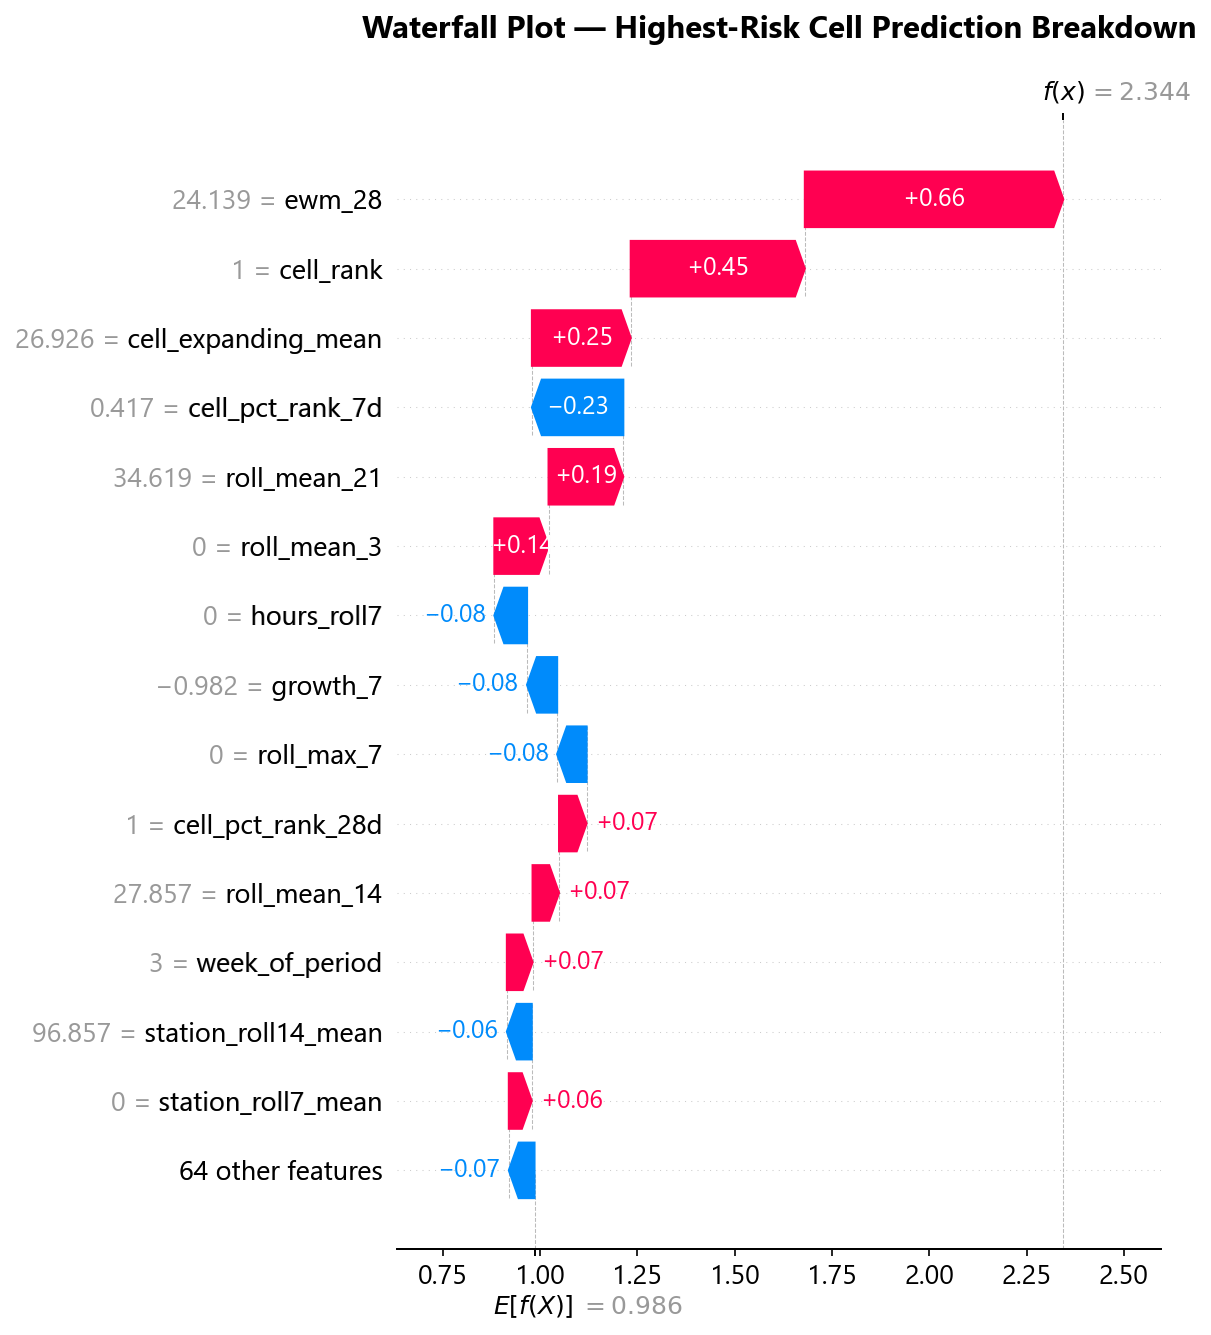

Saved: shap_plots/4_shap_waterfall_highrisk.png


In [8]:
pred_sums = shap_latest.values.sum(axis=1)
highest_idx = int(np.argmax(pred_sums))
pred_val = base_value + pred_sums[highest_idx]

print(f'Explaining prediction #{highest_idx}')
print(f'  Base value  : {base_value:.3f}')
print(f'  SHAP sum    : {pred_sums[highest_idx]:+.3f}')
print(f'  Final output: {pred_val:.3f}')

plt.figure(figsize=(12, 10))
shap.plots.waterfall(
    shap_latest[highest_idx],
    max_display=15,
    show=False
)
plt.title(
    'Waterfall Plot \u2014 Highest-Risk Cell Prediction Breakdown',
    fontsize=15, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '4_shap_waterfall_highrisk.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: shap_plots/4_shap_waterfall_highrisk.png')

---
## Graph 5: SHAP Force Plot (Single Prediction)

Red features push violations **higher**, blue push **lower**. Width = magnitude of contribution.

<Figure size 3300x600 with 0 Axes>

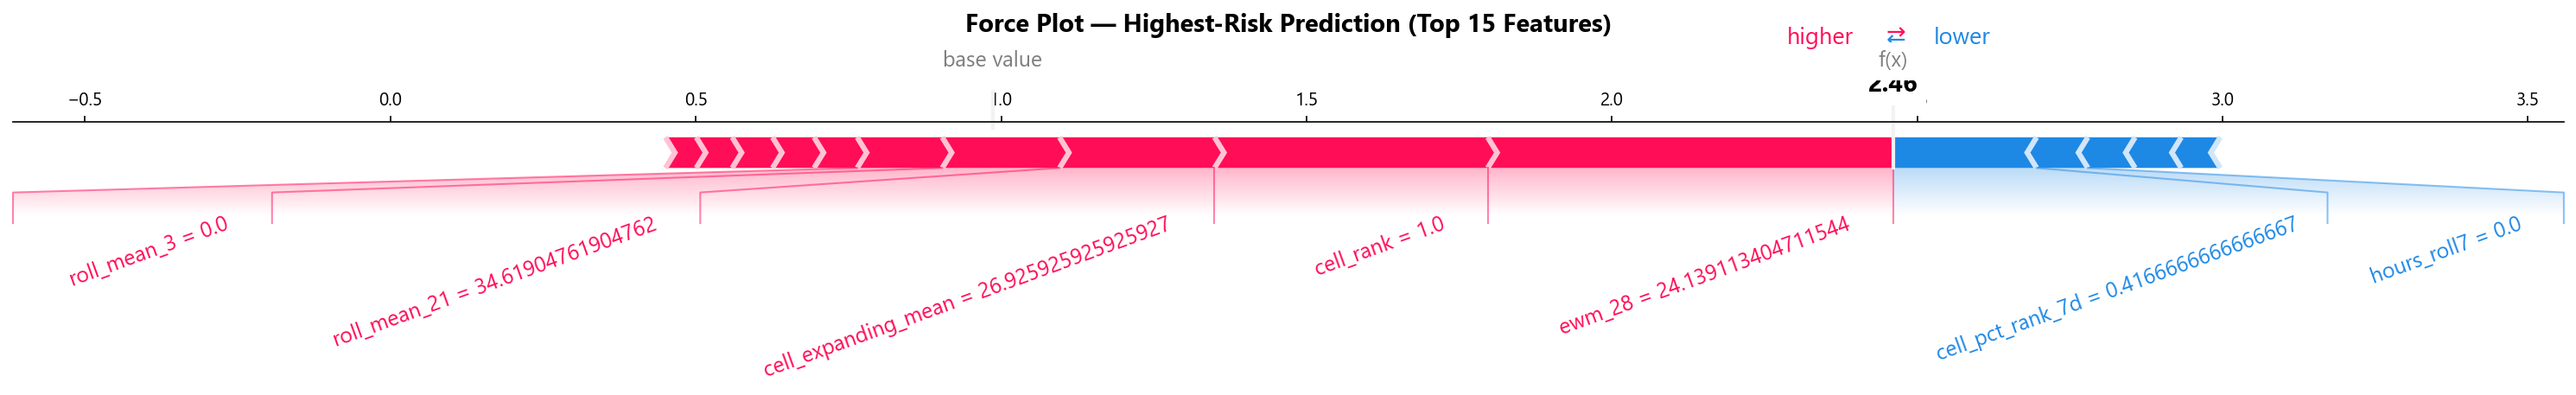

Saved: shap_plots/5_shap_force_plot.png


In [9]:
sv = shap_latest.values[highest_idx]
fv = X_latest.iloc[highest_idx].values
fn = list(F.FEATS_XGB)

# Top-15 features for readability
top_k = 15
top_idx = np.argsort(np.abs(sv))[-top_k:]

plt.figure(figsize=(22, 4))
shap.force_plot(
    base_value=base_value,
    shap_values=sv[top_idx],
    features=fv[top_idx],
    feature_names=[fn[i] for i in top_idx],
    matplotlib=True,
    show=False,
    text_rotation=20
)
plt.title(
    'Force Plot \u2014 Highest-Risk Prediction (Top 15 Features)',
    fontsize=14, fontweight='bold', pad=50
)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '5_shap_force_plot.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: shap_plots/5_shap_force_plot.png')

---
## Graph 6: SHAP Heatmap (Multi-Sample Patterns)

Each row = one prediction, each column = one feature. Color intensity = SHAP value.  
Reveals **clusters of prediction drivers** across H3 cells.

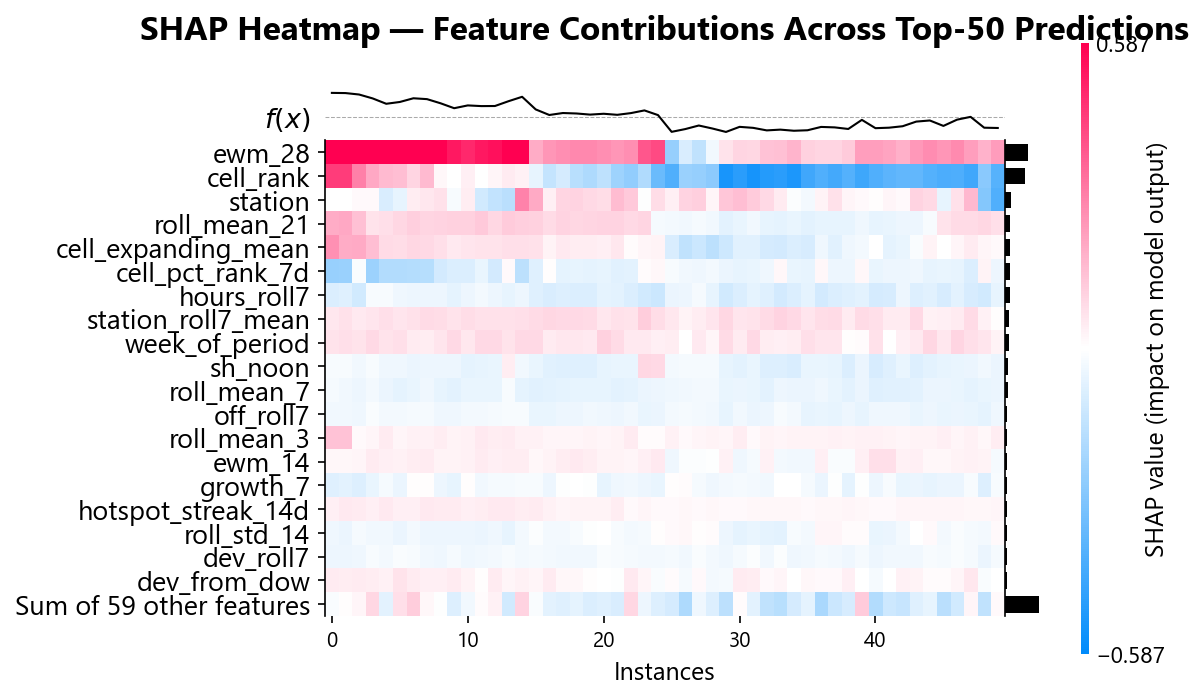

Saved: shap_plots/6_shap_heatmap.png


In [10]:
n_heatmap = min(50, len(shap_latest))
sort_order = np.argsort(shap_latest.values.sum(axis=1))[::-1][:n_heatmap]
shap_heatmap = shap_latest[sort_order]

plt.figure(figsize=(16, 10))
shap.plots.heatmap(
    shap_heatmap,
    max_display=20,
    show=False
)
plt.title(
    f'SHAP Heatmap \u2014 Feature Contributions Across Top-{n_heatmap} Predictions',
    fontsize=16, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '6_shap_heatmap.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: shap_plots/6_shap_heatmap.png')

---
## Summary Statistics

In [11]:
feat_names = [F.FEATS_XGB[i] for i in feat_ranking[:20]]
feat_mean  = [mean_abs_shap[i] for i in feat_ranking[:20]]
feat_max   = [np.abs(shap_sample.values[:, i]).max() for i in feat_ranking[:20]]
feat_sign  = [
    'Positive' if shap_sample.values[:, i].mean() > 0 else 'Negative'
    for i in feat_ranking[:20]
]

summary_df = pd.DataFrame({
    'Rank': range(1, 21),
    'Feature': feat_names,
    'Mean |SHAP|': [f'{v:.4f}' for v in feat_mean],
    'Max |SHAP|':  [f'{v:.4f}' for v in feat_max],
    'Avg Direction': feat_sign
}).set_index('Rank')

print('Top 20 Features by SHAP Importance:\n')
display(summary_df)

print(f'\n-- Model Info --')
print(f'Model            : XGBoost Poisson (24h violation count)')
print(f'SHAP method      : XGBoost native TreeSHAP (pred_contribs)')
print(f'Features         : {len(F.FEATS_XGB)} ({len(F.FEATS_NUM)} numeric + station)')
print(f'Samples analyzed : {len(X_sample)} (global) / {len(X_latest)} (latest day)')
print(f'Base prediction  : {base_value:.3f}')
print(f'Ridge weight     : {bundle["24h"]["ridge_w"][0]:.3f} (in 4-head ensemble)')

print(f'\nAll 6 XAI plots saved to: {PLOT_DIR}/')
for f in sorted(os.listdir(PLOT_DIR)):
    if f.endswith('.png'):
        sz = os.path.getsize(os.path.join(PLOT_DIR, f)) / 1024
        print(f'  {f}  ({sz:.0f} KB)')

Top 20 Features by SHAP Importance:



,Feature,Mean |SHAP|,Max |SHAP|,Avg Direction
Rank,,,,
1,ewm_28,0.4033,1.0222,Positive
2,cell_rank,0.3219,0.6608,Negative
3,station,0.1001,0.6025,Negative
4,cell_expanding_mean,0.0786,0.4156,Positive
5,roll_mean_21,0.0671,0.2435,Positive
6,hours_roll7,0.0554,0.2210,Negative
7,week_of_period,0.0494,0.1220,Positive
8,cell_pct_rank_7d,0.0453,0.2482,Negative
9,roll_mean_7,0.0434,0.1037,Negative



-- Model Info --
Model            : XGBoost Poisson (24h violation count)
SHAP method      : XGBoost native TreeSHAP (pred_contribs)
Features         : 78 (77 numeric + station)
Samples analyzed : 462 (global) / 66 (latest day)
Base prediction  : 0.986
Ridge weight     : 0.270 (in 4-head ensemble)

All 6 XAI plots saved to: C:\Users\WELCOME\Desktop\Flipkart\shap_plots/
  1_shap_beeswarm_summary.png  (495 KB)
  2_shap_feature_importance_bar.png  (245 KB)
  3_shap_dependence_scatter.png  (94 KB)
  4_shap_waterfall_highrisk.png  (275 KB)
  5_shap_force_plot.png  (310 KB)
  6_shap_heatmap.png  (204 KB)


---

## Interpretation Guide for PPT

1. **Beeswarm** - "Our model considers 70+ features. Top drivers are temporal lags and rolling averages — the model relies on **recent violation history** to forecast hotspots."

2. **Bar Plot** - "Feature importance via SHAP — a game-theoretic method giving each feature **fair credit** for its prediction contribution."

3. **Dependence** - "Feature-prediction relationships are **non-linear** — the model captures complex patterns that linear models miss."

4. **Waterfall** - "For the highest-risk zone, we trace **exactly which factors** pushed the prediction up — making the model **fully transparent**."

5. **Force Plot** - "Red = pushes violations UP, Blue = pushes DOWN. Each officer gets a clear, **actionable explanation** of why their zone is flagged."

6. **Heatmap** - "Distinct **clusters** of prediction drivers across H3 cells — some driven by weekends, others by persistence — enabling **tailored patrol strategies**."

---
*Flipkart GridLock Hackathon 2.0 — Patrol Forecast v6*